# Auf dem Laptop

Erstellen des Modells und speichern des Modells als tflite Datei.

In [23]:
import tensorflow as tf
from tensorflow.keras.layers import Dense, InputLayer
from tensorflow.keras.optimizers import Adam
import numpy as np
import matplotlib.pyplot as plt

In [31]:
# Erzeugen von 100 Graustufen-Bildern (komplett zufällige Pixelwerte)
# Erzeugen von 100 Labels
X_train = np.random.rand(100, 240, 320, 1)
y_train = np.random.rand(100)

In [32]:
image_shape = (240, 320, 1)

In [33]:
print("X_train Shape: ", X_train.shape)
print("y_train Shape: ", y_train.shape)

X_train Shape:  (100, 240, 320, 1)
y_train Shape:  (100,)


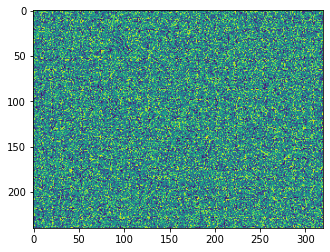

In [19]:
# Betrachten eines Beispielbildes
plt.imshow(X_train[0])

In [34]:
model = tf.keras.Sequential(
    [   
        Dense(2, activation="relu",input_shape = image_shape),
        Dense(3, activation="relu"),
        Dense(4, activation="relu"),
        Dense(1)
    ]
)


In [35]:
model.compile(loss ='mse', optimizer=Adam(learning_rate=0.001))

In [36]:
history = model.fit(
    X_train,
    y_train,
    batch_size=32,
    epochs= 1,
    verbose=1,
)

4/4 [==============================] - 4s 608ms/step - loss: 0.3647


### Wichtig: Das Modell im SavedModel Format abspeichern

Beim speichern des Modells einfach nur einen Namen angeben ohne Endung (also ohne ".h5" am Schluss).

In [37]:
model.save("Demo_Modell")

INFO:tensorflow:Assets written to: Demo_Modell\assets


Abgespeichertes Modell kann dann zu einem tflite Modell konvertiert werden. Dies ist das von Tensorflow selbst empfohlene Vorgehen ein .tflite Modell zu erstellen.

In [ ]:
converter = tf.lite.TFLiteConverter.from_saved_model("Demo_Modell")
tflite_model = converter.convert()
with open("TFLite_Modell.tflite", 'wb') as f:  
    f.write(tflite_model)


Durch das Abspeichern entsteht eine einzelne tflite-Datei, die auf den Pi übertragen werden kann und dort eingelesen werden kann.

Dazu muss auf dem Pi ggf. Tensorflow Lite nachinstalliert werden.

**ACHTUNG**: Der folgende Code funktioniert nur auf dem Pi!

In [ ]:
# Falls noch nicht installiert
!python3 -m pip install tflite-runtime

In [ ]:
# Auf Raspi
import tflite_runtime.interpreter as tflite
interpreter = tflite.Interpreter(model_path=path) # path=Pfad zur .tflite Datei
input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()
interpreter.allocate_tensors()

In [ ]:
# Ggf. nicht vergessen Vorverarbeitungsschritte (hier nur beispielhaft)
img = cv2.imread("image.jpg")
new_img = cv2.resize(img, (300, 300))
new_img = new_img.astype(np.float32)
new_img /= 255.

In [ ]:
# Prediction
# Hier muss nur für new_img das Bild übergeben werden, der Rest des Codes sollte nicht verändert werden
interpreter.set_tensor(input_details[0]['index'], new_img)
interpreter.invoke() 
output_data = interpreter.get_tensor(output_details[0]['index'])
output_data 
